In [21]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem
from pynamicalsys import TimeSeriesMetrics
from pynamicalsys import PlotStyler
from string import ascii_lowercase as abc
from scipy.stats import pearsonr

home_dir = os.path.expanduser("~")
path_to_data = f"{home_dir}/Research/recurrence-two-dof"
os.makedirs("figures/", exist_ok=True)

# Hénon-Heiles

## Fig. 1

In [2]:
energies = [1 / i for i in range(6, 11)]
energies = energies[::-1]
n_cross = 5000
num_ic = 200

<Figure size 640x480 with 0 Axes>

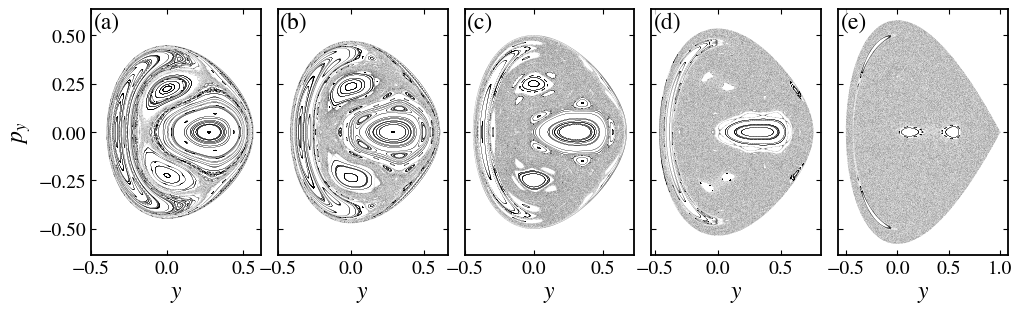

In [3]:
fontsize = 17
ps = PlotStyler(fontsize=fontsize)
ps.apply_style()

fig, ax = plt.subplots(1, 5, sharey=True, figsize=(10, 3))

for i, energy in enumerate(energies):
    df = f"{path_to_data}/henon_heiles/data/pss_E={energy:.5f}_n={n_cross}.dat"
    df = pd.read_csv(df, header=None, sep=r"\s+")
    ax[i].scatter(df[2], df[4], s=0.01, color="k", edgecolor="none")
    ax[i].set_xlabel("$y$")
    if i in [0, 1, 2, 3]:
        ax[i].set_xticks([-0.5, 0, 0.5])
    else:
        ax[i].set_xticks([-0.5, 0, 0.5, 1.0])
ax[0].set_ylabel("$p_y$")

bbox = {"facecolor": "w", "linewidth": 0.0, "alpha": 0.75, "pad": 1}
xbox = 0.015
ybox = 0.923
for i in range(len(ax)):
    ax[i].text(xbox, ybox, f"({abc[i]})", transform=ax[i].transAxes, bbox=bbox)

plt.subplots_adjust(left=0.078, bottom=0.17, right=0.995, top=0.99, wspace=0.1)
plt.savefig("figures/fig1.png", dpi=400)

## Fig. 2

In [4]:
from henon_heiles.model import px_from_E

ds = HamiltonianSystem(model="henon heiles")

In [5]:
energy = 1 / 9
n_cross = 20000
q_vals = np.array([[0.0, -0.15], [0.0, 0.0], [0, -0.125]])
py_vals = [0.0, 0.0, -0.127]
p_vals = []
for i in range(len(q_vals)):
    py = py_vals[i]
    info, px = px_from_E(energy, q_vals[i], py)
    p_vals.append([px, py])

In [6]:
all_pss = np.zeros((len(q_vals), n_cross, 2))
for i in range(len(q_vals)):
    pss = ds.poincare_section(q_vals[i], p_vals[i], n_cross)
    all_pss[i, :, 0] = pss[:, 2]
    all_pss[i, :, 1] = pss[:, 4]

In [7]:
rec_points = 2000
all_recmats = np.zeros((len(q_vals), rec_points, rec_points))
all_distrs = np.zeros((len(q_vals), rec_points - 1))
for i in range(len(q_vals)):
    tsm = TimeSeriesMetrics(all_pss[i, :rec_points])
    recmat, distr = tsm.recurrence_matrix(
        threshold_mode="std", threshold=0.05, compute_white_vert_distr=True
    )
    all_recmats[i] = recmat
    all_distrs[i] = distr

In [8]:
fontsize = 18
ps = PlotStyler(fontsize=fontsize)
ps.apply_style()

fig, ax = plt.subplots(2, 3, figsize=(10, 5))

colors = ["r", "b", "g"]
df = f"{path_to_data}/henon_heiles/data/pss_E={energy:.5f}_n={5000}.dat"
df = pd.read_csv(df, header=None, sep=r"\s+")


ax[0, 0].plot(df[2], df[4], "ko", ms=0.1, markeredgewidth=0)
i = 0
ax[0, 0].plot(
    all_pss[i, :, 0], all_pss[i, :, 1], "o", c=colors[i], ms=0.4, markeredgewidth=0
)
ax[0, 0].set_xlabel("$y$")
ax[0, 0].set_ylabel("$p_y$")
ax[0, 0].set_xticks([-0.5, 0, 0.5])

ax[0, 1].plot(df[2], df[4], "ko", ms=0.3, markeredgewidth=0)
i = 1
ax[0, 1].plot(
    all_pss[i, :, 0], all_pss[i, :, 1], "o", c=colors[i], ms=0.8, markeredgewidth=0
)
ax[0, 1].set_xlim(-0.05, 0.55)
ax[0, 1].set_ylim(-0.22, 0.22)
ax[0, 1].set_xlabel("$y$")
ax[0, 1].set_ylabel("$p_y$")

ax[0, 2].plot(df[2], df[4], "ko", ms=0.3, markeredgewidth=0)
i = 2
ax[0, 2].plot(
    all_pss[i, :, 0], all_pss[i, :, 1], "o", c=colors[i], ms=0.6, markeredgewidth=0
)
ax[0, 2].set_xlim(-0.2, 0.205)
ax[0, 2].set_ylim(-0.33, -0.08)
ax[0, 2].set_xlabel("$y$")
ax[0, 2].set_ylabel("$p_y$")

for i in range(all_pss.shape[0]):

    recmat = all_recmats[i]
    y_rec, x_rec = np.where(recmat == 1)
    ax[1, i].plot(x_rec, y_rec, "o", c=colors[i], ms=0.35, markeredgewidth=0)
    ax[1, i].set_xlim(0, rec_points)
    ax[1, i].set_ylim(0, rec_points)
    ax[1, i].set_xlabel("$i$")
    ax[1, i].set_ylabel("$j$")

plt.subplots_adjust(
    left=0.075, bottom=0.095, right=0.979, top=0.99, wspace=0.32, hspace=0.28
)

bbox = {"facecolor": "w", "linewidth": 0.0, "alpha": 0.75, "pad": 1}
xbox = 0.011
ybox = 0.899
for i in range(len(ax.flat)):
    ax.flat[i].text(
        xbox, ybox, f"({abc[i]})", transform=ax.flat[i].transAxes, bbox=bbox
    )
plt.savefig("figures/fig2.png", dpi=400)
plt.close()

<Figure size 640x480 with 0 Axes>

## Fig. 3

In [9]:
t_total = 1e5
n_cross = 10000
num_y = 5000
energy = 1 / 8
std_scales = [0.01, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]
std_scales_to_plot = [0.01, 0.05, 0.1, 0.2]
datafile = f"{path_to_data}/henon_heiles/data/lle_vs_y_E={energy:.5f}_T={t_total:.0f}_num_y={num_y}.dat"
df = pd.read_csv(datafile, header=None, sep=r"\s+")

<Figure size 640x480 with 0 Axes>

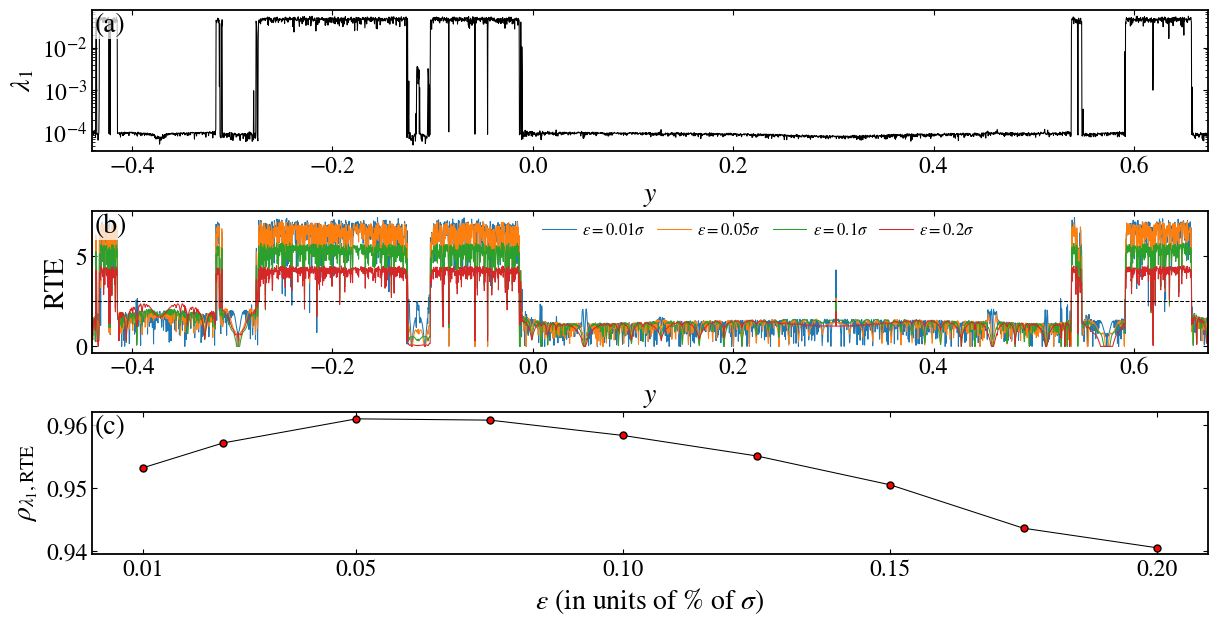

In [10]:
fontsize = 20
ps = PlotStyler(fontsize=fontsize, linewidth=0.75, legend_fontsize=12)
ps.apply_style()

fig, ax = plt.subplots(3, 1, figsize=(12, 6))

datafile = f"{path_to_data}/henon_heiles/data/lle_vs_y_E={energy:.5f}_T={t_total:.0f}_num_y={num_y}.dat"
df = pd.read_csv(datafile, header=None, sep=r"\s+")
y = np.array(df[0])
lle = np.array(df[1])
mask = ~np.isnan(lle)
y = y[mask]
lle = lle[mask]

ax[0].plot(y, lle, "k")
ax[0].set_yscale("log")
ax[0].set_xlim(y.min(), y.max())
ax[1].set_xlim(y.min(), y.max())
ax[0].set_ylabel(r"$\lambda_1$")
ax[0].set_xlabel("$y$")

corr_coef = []
j = 0
# std_scales = [0.2, 0.15, 0.1, 0.05, 0.01]
# colors = ["k", "r", "g", "b", "darkviolet"]
colors = sns.color_palette("tab10", len(std_scales_to_plot))
for i, std_scale in enumerate(std_scales):
    datafile = f"{path_to_data}/henon_heiles/data/rte_vs_y_E={energy:.5f}_N={n_cross}_num_y={num_y}_scale={std_scale:.3f}.dat"
    df = pd.read_csv(datafile, header=None, sep=r"\s+")
    y = np.array(df[0])
    rte = np.array(df[1])
    mask = ~np.isnan(rte)
    y = y[mask]
    rte = rte[mask]
    r, p_value = pearsonr(lle, rte)
    corr_coef.append(r)
    if std_scale in std_scales_to_plot:
        ax[1].plot(y, rte, c=colors[j], label=rf"$\epsilon = {std_scale}\sigma$")
        j += 1
ax[1].axhline(2.5, ls="--", c="k")
# ax[1].legend(loc="lower left", ncol=2, frameon=False, columnspacing=0.7, bbox_to_anchor=(0.39, 0.53), handletextpad=0.4)
ax[1].legend(
    loc="lower left",
    ncol=4,
    frameon=False,
    columnspacing=0.7,
    bbox_to_anchor=(0.39, 0.7),
    handletextpad=0.4,
)

ax[1].set_xlabel("$y$")
ax[1].set_ylabel("RTE")

ax[2].set_ylabel(r"$\rho_{\lambda_1, \mathrm{RTE}}$")
ax[2].set_xlabel(r"$\epsilon$ (in units of % of $\sigma$)")
ax[2].plot(std_scales, corr_coef, "k-")
ax[2].plot(std_scales, corr_coef, "ro")
ax[2].set_xticks([0.01, 0.05, 0.1, 0.15, 0.2])
# ax[2].set_ylim(0.935, 0.97)

xbox = 0.002
ybox = 0.847
bbox = {"facecolor": "w", "linewidth": 0.0, "alpha": 0.75, "pad": 1}
for i in range(ax.shape[0]):
    ax[i].text(xbox, ybox, f"({abc[i]})", transform=ax[i].transAxes, bbox=bbox)

plt.subplots_adjust(left=0.068, bottom=0.09, right=0.9975, top=0.9975, hspace=0.42)
plt.savefig("figures/fig3.png", dpi=400)

## Fig. 4

In [11]:
energies = [1 / i for i in range(6, 11)][::-1]
# energies = [1/8]
grid_size = 1000
t_total = 1e5
n_cross = 10000
std_scale = 0.05

<Figure size 640x480 with 0 Axes>

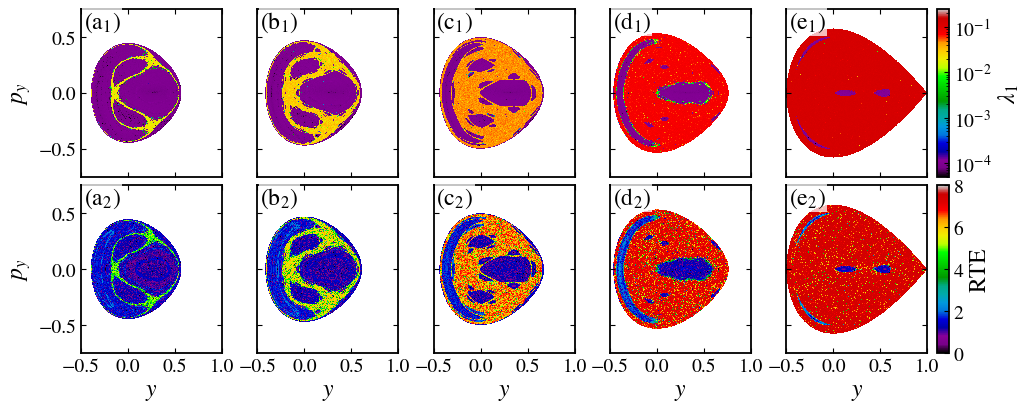

In [12]:
fontsize = 17
ps = PlotStyler(fontsize=fontsize, linewidth=0.75, legend_fontsize=12)
ps.apply_style()

fig, ax = plt.subplots(2, 5, sharex=True, sharey=True, figsize=(10, 4))

xbox = 0.018
ybox = 0.8875
bbox = {"facecolor": "w", "linewidth": 0.0, "alpha": 0.75, "pad": 1}

for i, energy in enumerate(energies):
    datafile = f"{path_to_data}/henon_heiles/data/grid_lle_E={energy:.5f}_T={t_total:.0f}_grid_size={grid_size}.dat"
    df = pd.read_csv(datafile, header=None, sep=r"\s+")
    y = np.array(df[0]).reshape(grid_size, grid_size)
    py = np.array(df[1]).reshape(grid_size, grid_size)
    mle = np.array(df[2]).reshape(grid_size, grid_size)
    hm = ax[0, i].pcolormesh(
        y,
        py,
        mle,
        cmap="nipy_spectral",
        norm=mpl.colors.LogNorm(vmin=5e-5, vmax=0.25e-0),
    )

    datafile = f"{path_to_data}/henon_heiles/data/grid_rte_E={energy:.5f}_N={n_cross}_grid_size={grid_size}_scale={std_scale:.3f}.dat"
    df = pd.read_csv(datafile, header=None, sep=r"\s+")
    y = np.array(df[0]).reshape(grid_size, grid_size)
    py = np.array(df[1]).reshape(grid_size, grid_size)
    rte = np.array(df[2]).reshape(grid_size, grid_size)
    hm2 = ax[1, i].pcolormesh(y, py, rte, cmap="nipy_spectral", vmin=0, vmax=8)
    ax[1, i].set_xlabel("$y$")
    ax[0, i].text(
        xbox, ybox, f"({abc[i]}$_1$)", transform=ax[0, i].transAxes, bbox=bbox
    )
    ax[1, i].text(
        xbox, ybox, f"({abc[i]}$_2$)", transform=ax[1, i].transAxes, bbox=bbox
    )
ax[0, 0].set_ylabel("$p_y$")
ax[1, 0].set_ylabel("$p_y$")
ax[0, 0].set_xticks([-0.5, 0, 0.5, 1])

plt.subplots_adjust(
    left=0.0675, bottom=0.13, right=1.075, top=0.99, hspace=0.05, wspace=0.25
)
cbar = plt.colorbar(hm, ax=ax[0, :], label=r"$\lambda_1$", pad=0.01, aspect=15)
cbar = plt.colorbar(hm2, ax=ax[1, :], label="RTE", pad=0.01, aspect=15)

plt.savefig("figures/fig4.png", dpi=400)

## Fig. 5

/var/folders/t2/0pjgc7ld2kl12tt4b_qr4d4h0000gn/T/ipykernel_91927/320852299.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("nipy_spectral")


24999999
24999999
24999999


<Figure size 640x480 with 0 Axes>

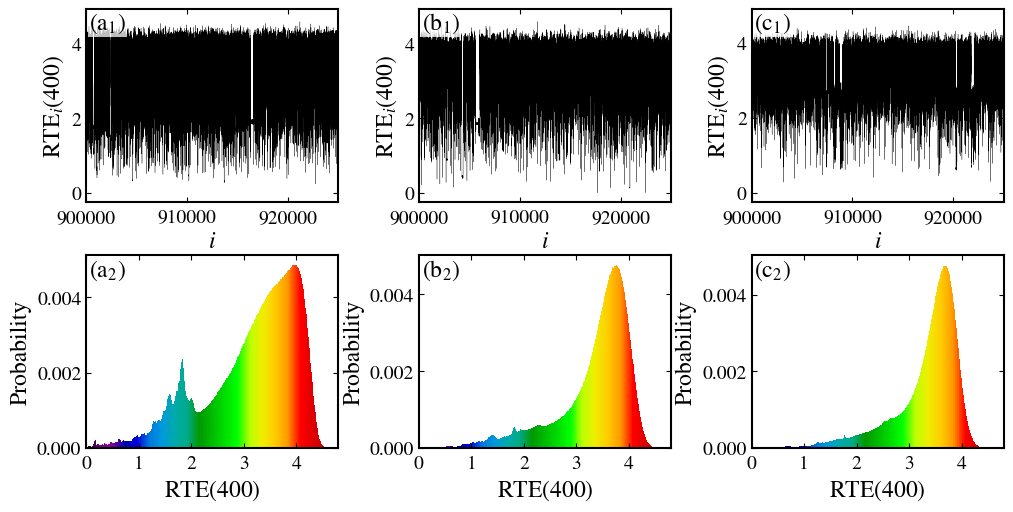

In [13]:
from matplotlib import cm, colors

fontsize = 17
ps = PlotStyler(fontsize=fontsize, axes_linewidth=1.5)
ps.apply_style()

fig, ax = plt.subplots(2, 3, figsize=(10, 5))


cmap = cm.get_cmap("nipy_spectral")
# === Parameters ===
energies = [1 / 9, 1 / 8, 1 / 7]
total_crossing = int(1e10)
finite_crossing = 400

for j, energy in enumerate(energies):
    datafile = f"{path_to_data}/henon_heiles/data/finite_time_rte_E={energy:.5f}_N={total_crossing}_n={finite_crossing}_save_pss=0.dat"
    df = pd.read_csv(datafile, header=None, sep=r"\s+")
    values = df[0].iloc[:-1].to_numpy()
    print(len(values))
    counts, bins = np.histogram(values, bins="auto")
    probabilities = counts / counts.sum()
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    ax[0, j].plot(values, "k", lw=0.2)
    ax[0, j].set_xlim(9e5, 9.25e5)
    ax[0, j].set_ylabel(f"RTE$_i$({finite_crossing})")
    ps.set_tick_padding(ax[0, j], pad_x=5)
    ax[0, j].set_xlabel("$i$")

    norm = colors.Normalize(vmin=0, vmax=4.8)

    for i in range(len(probabilities)):
        ax[1, j].bar(
            bin_centers[i],
            probabilities[i],
            width=bins[1] - bins[0],
            color=cmap(norm(bin_centers[i])),
            align="center",
            edgecolor="none",
        )

    ax[1, j].set_xlim(0, 4.8)
    ax[1, j].set_xticks([0, 1, 2, 3, 4])
    ax[1, j].set_ylabel("Probability")
    ax[1, j].set_xlabel(rf"$\mathrm{{RTE}}({finite_crossing})$")

    ps.set_tick_padding(ax[1, j], pad_x=5)


xbox = 0.0112
ybox = 0.895
bbox = {"facecolor": "w", "linewidth": 0.0, "alpha": 0.75, "pad": 1}
for i in range(ax.shape[1]):
    ax[0, i].text(
        xbox, ybox, f"({abc[i]}$_1$)", transform=ax[0, i].transAxes, bbox=bbox
    )
    ax[1, i].text(
        xbox, ybox, f"({abc[i]}$_2$)", transform=ax[1, i].transAxes, bbox=bbox
    )

plt.subplots_adjust(
    left=0.08, bottom=0.12, right=0.9975, top=0.9975, wspace=0.32, hspace=0.28
)
plt.savefig("figures/fig5.png", dpi=400)
plt.show()

## Fig. 6

In [14]:
def get_ypy_range(E, idf):
    if E == 1 / 9:
        if idf == 1:
            y_range = (-0.12, -0.04)
            py_range = (-0.1, 0.1)
        elif idf == 2:
            y_range = (-0.185, -0.1)
            py_range = (0.08, 0.2)
        elif idf == 3:
            y_range = (0.08, 0.24)
            py_range = (0.32, 0.43)
    elif E == 1 / 8:
        if idf == 1:
            y_range = (-0.05, 0.18)
            py_range = (0.02, 0.14)
        elif idf == 2:
            y_range = (-0.15, -0.05)
            py_range = (0.12, 0.2)
        elif idf == 3:
            y_range = (-0.315, -0.27)
            py_range = (-0.17, 0.17)
    elif E == 1 / 7:
        if idf == 1:
            y_range = (-0.05, 0.18)
            py_range = (0.00, 0.1)
        elif idf == 2:
            y_range = (0.0, 0.2)
            py_range = (-0.275, -0.2)
        elif idf == 3:
            y_range = (-0.025, 0.1)
            py_range = (0.41, 0.5)

    return y_range, py_range

In [15]:
energies = [1 / 9, 1 / 8, 1 / 7]
total_crossing = int(5e7)
finite_crossing = 400

In [ ]:
fontsize = 17
ps = PlotStyler(fontsize=fontsize)
ps.apply_style()

fig, ax = plt.subplots(3, 4, figsize=(10, 6))

for j, energy in enumerate(energies):
    datafile = f"{path_to_data}/henon_heiles/data/finite_time_rte_E={energy:.5f}_N={total_crossing}_n={finite_crossing}_save_pss=1.dat"
    df = pd.read_csv(datafile, header=None, sep=r"\s+")
    values = df[2].iloc[:-1].to_numpy()
    ax[j, 0].scatter(
        df[0],
        df[1],
        c=df[2],
        cmap="nipy_spectral",
        edgecolor="none",
        s=0.025,
        vmin=0,
        vmax=4.8,
    )

    for i in range(3):
        hm = ax[j, i + 1].scatter(
            df[0],
            df[1],
            c=df[2],
            cmap="nipy_spectral",
            edgecolor="none",
            s=0.05,
            vmin=0,
            vmax=4.8,
        )
        y_range, py_range = get_ypy_range(energy, i + 1)
        ax[j, i + 1].set_xlim(*y_range)
        ax[j, i + 1].set_ylim(*py_range)

for i in range(ax.shape[1]):
    ax[-1, i].set_xlabel("$y$")
for i in range(ax.shape[0]):
    ax[i, 0].set_ylabel("$p_y$")

xbox = 0.0136
ybox = 0.881
bbox = {"facecolor": "w", "linewidth": 0.0, "alpha": 0.75, "pad": 1}
for i in range(ax.shape[0] * ax.shape[1]):
    ax.flat[i].text(
        xbox, ybox, f"({abc[i]})", transform=ax.flat[i].transAxes, bbox=bbox
    )

plt.subplots_adjust(left=0.068, bottom=0.085, right=1.085, top=0.985, wspace=0.32)

plt.colorbar(hm, ax=ax, label="RTE", pad=0.015, aspect=50)
plt.savefig("figures/fig6.png", dpi=400)
plt.close()

## Fig. 7

In [2]:
def get_run_lengths(mask):
    """
    Return lengths of contiguous True runs in a boolean array.
    """
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return np.array([], dtype=int)

    # Pad with False at both ends so transitions are easy to detect
    padded = np.concatenate(([False], mask, [False])).astype(int)
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    return ends - starts


def cumulative_distribution(run_lengths):
    """
    Returns tau values and Q(tau) = Pr(T > tau).
    """
    run_lengths = np.asarray(run_lengths, dtype=int)

    if run_lengths.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    tau = np.arange(0, run_lengths.max() + 1)
    Q = np.array([(run_lengths > t).sum() / run_lengths.size for t in tau], dtype=float)

    return tau, Q

In [3]:
m = 3  # minimum persistence (in windows)

energies = [1 / 9, 1 / 8, 1 / 7]
total_crossing = int(1e10)
finite_crossing = 400

low_rte_runs = {}
high_rte_runs = {}

low_cumulative = {}
high_cumulative = {}

for energy in energies:

    datafile = (
        f"{path_to_data}/henon_heiles/data/"
        f"finite_time_rte_E={energy:.5f}"
        f"_N={total_crossing}"
        f"_n={finite_crossing}"
        f"_save_pss=0.dat"
    )

    df = pd.read_csv(datafile, header=None, sep=r"\s+")

    values = df[0].iloc[:-1].to_numpy()

    # ==================================================
    # raw masks
    # ==================================================

    low_mask = values < 2.0
    high_mask = values > 3.0

    # ==================================================
    # persistence filter
    # require m consecutive windows
    # ==================================================

    kernel = np.ones(m, dtype=int)
    low_persistent = np.convolve(low_mask.astype(int), kernel, mode="same") >= m
    high_persistent = np.convolve(high_mask.astype(int), kernel, mode="same") >= m

    # ==================================================
    # run lengths
    # ==================================================

    low_runs = get_run_lengths(low_persistent)
    high_runs = get_run_lengths(high_persistent)
    low_rte_runs[energy] = low_runs
    high_rte_runs[energy] = high_runs

    # ==================================================
    # cumulative distributions
    # ==================================================

    tau_low, Q_low = cumulative_distribution(low_runs)
    tau_high, Q_high = cumulative_distribution(high_runs)
    low_cumulative[energy] = (
        tau_low,
        Q_low,
    )
    high_cumulative[energy] = (
        tau_high,
        Q_high,
    )

    print(f"\nE = {energy:.5f}")
    print(f"sticky episodes: " f"{len(low_runs)}")
    print(f"chaotic episodes: " f"{len(high_runs)}")


E = 0.11111
sticky episodes: 266817
chaotic episodes: 1981852

E = 0.12500
sticky episodes: 97859
chaotic episodes: 2152697

E = 0.14286
sticky episodes: 80456
chaotic episodes: 2158514


E=0.11111, gamma=1.19386
E=0.11111, kappa=0.20337
E=0.12500, gamma=1.26116
E=0.12500, kappa=0.16596
E=0.14286, gamma=1.59219
E=0.14286, kappa=0.16280


<Figure size 640x480 with 0 Axes>

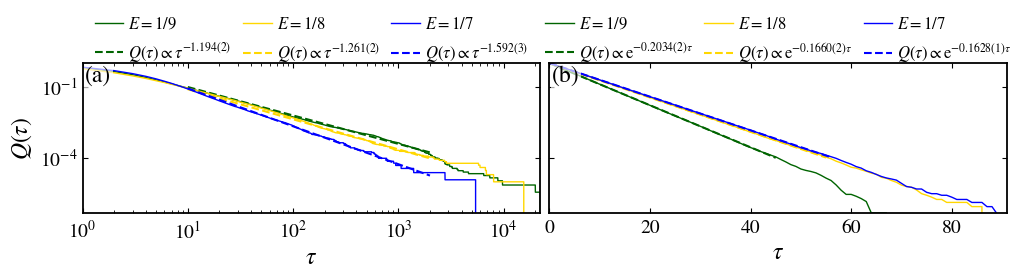

In [4]:
ps = PlotStyler(fontsize=17, legend_fontsize=12)

ps.apply_style()

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 2.5))

ps.set_tick_padding(ax[0], pad_x=5)
ps.set_tick_padding(ax[1], pad_x=5)

colors = sns.color_palette("tab10", 3)

labels = [
    r"$E = 1/9$",
    r"$E = 1/8$",
    r"$E = 1/7$",
]

low_max_tau = 0
high_max_tau = 0

tau_min = 10
tau_max = 2e3


colors = ["darkgreen", "gold", "blue"]
for i, energy in enumerate(energies):

    # ==================================================
    # LOW RTE (sticky)
    # power law
    # ==================================================

    tau, Q = low_cumulative[energy]
    mask_nonzero = Q > 0

    if np.any(mask_nonzero):
        low_max_tau = max(low_max_tau, tau[mask_nonzero][-1])

    ax[0].loglog(
        tau,
        Q,
        c=colors[i],
        label=labels[i],
    )

    mask_fit = (tau >= tau_min) & (tau <= tau_max) & (Q > 0)

    x_fit = tau[mask_fit]
    y_fit = Q[mask_fit]

    if len(x_fit) > 3:

        coeffs, cov = np.polyfit(
            np.log10(x_fit),
            np.log10(y_fit),
            1,
            cov=True,
        )

        slope, intercept = coeffs

        gamma = -slope
        std_gamma = np.sqrt(cov[0, 0])

        num_digits = max(0, -int(np.log10(std_gamma)) + 1)

        uncert = int(round(std_gamma * 10**num_digits))

        gamma_label = rf"{gamma:.{num_digits}f}" rf"({uncert})"

        print(f"E={energy:.5f}, " f"gamma={gamma:.5f}")

        x_new = np.logspace(
            np.log10(tau_min),
            np.log10(tau_max),
            1000,
        )

        y_new = 10**intercept * x_new**slope

        ax[0].plot(
            x_new,
            y_new,
            "--",
            c=colors[i],
            label=rf"$Q(\tau) \propto \tau^{{-{gamma_label}}}$",
            lw=1.5,
        )

    # ==================================================
    # HIGH RTE (chaotic)
    # exponential
    # ==================================================

    tau, Q = high_cumulative[energy]

    mask_nonzero = Q > 0

    if np.any(mask_nonzero):
        high_max_tau = max(high_max_tau, tau[mask_nonzero][-1])

    ax[1].semilogy(
        tau,
        Q,
        c=colors[i],
        label=labels[i],
    )

    mask_fit = (Q > 1e-4) & (Q > 0)

    x_fit = tau[mask_fit]
    y_fit = Q[mask_fit]

    if len(x_fit) > 3:

        coeffs, cov = np.polyfit(
            x_fit,
            np.log(y_fit),
            1,
            cov=True,
        )

        slope, logA = coeffs
        kappa = -slope
        A = np.exp(logA)
        std_kappa = np.sqrt(cov[0, 0])
        num_digits = max(0, -int(np.log10(std_kappa)) + 1)
        uncert = int(round(std_kappa * 10**num_digits))
        kappa_label = rf"{kappa:.{num_digits}f}" rf"({uncert})"

        print(f"E={energy:.5f}, " f"kappa={kappa:.5f}")

        x_new = np.linspace(
            x_fit.min(),
            x_fit.max(),
            1000,
        )

        y_new = A * np.exp(slope * x_new)
        ax[1].plot(
            x_new,
            y_new,
            "--",
            c=colors[i],
            label=rf"$Q(\tau) \propto \mathrm{{e}}^{{-{kappa_label}\tau}}$",
            lw=1.5,
        )


# ==================================================
# formatting
# ==================================================

ax[0].set_ylim(5e-7, 1e0)
ax[0].set_xlim(1, low_max_tau + 1)
ax[1].set_xlim(0, high_max_tau + 1)
ax[0].set_ylabel(r"$Q(\tau)$")
ax[0].set_xlabel(r"$\tau$")
ax[1].set_xlabel(r"$\tau$")

for i in range(2):
    ax[i].legend(
        frameon=False,
        ncol=3,
        columnspacing=0.7,
        handlelength=1.7,
        handletextpad=0.3,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.41),
    )

xbox = 0.0055
ybox = 0.874

bbox = {
    "facecolor": "w",
    "linewidth": 0.0,
    "alpha": 0.65,
    "pad": 1,
}

for i in range(2):

    ax[i].text(
        xbox,
        ybox,
        f"({abc[i]})",
        transform=ax[i].transAxes,
        bbox=bbox,
    )

plt.subplots_adjust(
    left=0.0725,
    bottom=0.2,
    right=0.997,
    top=0.8,
    wspace=0.02,
)

plt.savefig(
    "figures/fig7.png",
    dpi=600,
)

## Fig. 8

In [5]:
def get_run_lengths(mask):
    """
    Return lengths of contiguous True runs in a boolean array.
    """
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return np.array([], dtype=int)

    # Pad with False at both ends so transitions are easy to detect
    padded = np.concatenate(([False], mask, [False])).astype(int)
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    return ends - starts


def cumulative_distribution(run_lengths):
    """
    Returns tau values and Q(tau) = Pr(T > tau).
    """
    run_lengths = np.asarray(run_lengths, dtype=int)

    if run_lengths.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    tau = np.arange(0, run_lengths.max() + 1)
    Q = np.array([(run_lengths > t).sum() / run_lengths.size for t in tau], dtype=float)

    return tau, Q

In [6]:
energies = np.linspace(1 / 10, 1 / 6, 50)
total_crossing = int(1e10)
finite_crossing = 400
m = 3  # persistence in windows

results = {}

for energy in energies:

    datafile = (
        f"{path_to_data}/henon_heiles/data/"
        f"finite_time_rte_E={energy:.5f}"
        f"_N={total_crossing}"
        f"_n={finite_crossing}"
        f"_save_pss=0.dat"
    )

    df = pd.read_csv(datafile, header=None, sep=r"\s+")

    values = df[0].iloc[:-1].to_numpy()

    # ==================================================
    # raw masks
    # ==================================================

    low_mask = values < 2.0
    high_mask = values > 3.0

    # ==================================================
    # persistence filter
    # ==================================================

    kernel = np.ones(m, dtype=int)

    low_persistent = np.convolve(low_mask.astype(int), kernel, mode="same") >= m

    high_persistent = np.convolve(high_mask.astype(int), kernel, mode="same") >= m

    # ==================================================
    # run lengths
    # ==================================================

    low_runs = get_run_lengths(low_persistent)

    high_runs = get_run_lengths(high_persistent)

    # ==================================================
    # cumulative distributions
    # ==================================================

    tau_low, Q_low = cumulative_distribution(low_runs)

    tau_high, Q_high = cumulative_distribution(high_runs)

    # ==================================================
    # sticky region
    # power law:
    # Q(tau) ~ tau^{-gamma}
    # ==================================================

    gamma = np.nan
    gamma_r2 = np.nan

    tau_min = 10
    tau_max = 1e3

    mask = (tau_low >= tau_min) & (tau_low <= tau_max) & (Q_low > 0)

    x_fit = tau_low[mask]
    y_fit = Q_low[mask]

    if len(x_fit) > 3:

        coeffs = np.polyfit(np.log10(x_fit), np.log10(y_fit), 1)

        slope, intercept = coeffs

        gamma = -slope

        y_pred = intercept + slope * np.log10(x_fit)

        ss_res = np.sum((np.log10(y_fit) - y_pred) ** 2)

        ss_tot = np.sum((np.log10(y_fit) - np.mean(np.log10(y_fit))) ** 2)

        gamma_r2 = 1 - ss_res / ss_tot

    # ==================================================
    # chaotic region
    # exponential:
    # Q(tau) ~ exp(-kappa tau)
    # ==================================================

    kappa = np.nan
    kappa_r2 = np.nan

    mask = (Q_high > 1e-4) & (Q_high > 0)

    x_fit = tau_high[mask]
    y_fit = Q_high[mask]

    if len(x_fit) > 3:

        coeffs = np.polyfit(x_fit, np.log(y_fit), 1)

        slope, logA = coeffs

        kappa = -slope

        y_pred = logA + slope * x_fit

        ss_res = np.sum((np.log(y_fit) - y_pred) ** 2)

        ss_tot = np.sum((np.log(y_fit) - np.mean(np.log(y_fit))) ** 2)

        kappa_r2 = 1 - ss_res / ss_tot

    # ==================================================
    # store
    # ==================================================

    results[energy] = {
        "tau_low": tau_low,
        "Q_low": Q_low,
        "gamma": gamma,
        "gamma_r2": gamma_r2,
        "low_runs": low_runs,
        "tau_high": tau_high,
        "Q_high": Q_high,
        "kappa": kappa,
        "kappa_r2": kappa_r2,
        "high_runs": high_runs,
    }

    print(f"\nE = {energy:.5f}")
    print(f"sticky episodes: " f"{len(low_runs)}")
    print(f"chaotic episodes: " f"{len(high_runs)}")
    print(f"gamma = " f"{gamma:.5f} " f"(R² = {gamma_r2:.5f})")
    print(f"kappa = " f"{kappa:.5e} " f"(R² = {kappa_r2:.5f})")


E = 0.10000
sticky episodes: 386154
chaotic episodes: 1751617
gamma = 1.21484 (R² = 0.99448)
kappa = 3.96230e-01 (R² = 0.99997)

E = 0.10136
sticky episodes: 551674
chaotic episodes: 1654419
gamma = 1.76332 (R² = 0.98153)
kappa = 3.41213e-01 (R² = 0.99999)

E = 0.10272
sticky episodes: 551759
chaotic episodes: 1614938
gamma = 1.17555 (R² = 0.99042)
kappa = 3.37412e-01 (R² = 0.99988)

E = 0.10408
sticky episodes: 341559
chaotic episodes: 1901873
gamma = 1.67875 (R² = 0.99351)
kappa = 3.22938e-01 (R² = 0.99998)

E = 0.10544
sticky episodes: 312478
chaotic episodes: 2073521
gamma = 1.57484 (R² = 0.99809)
kappa = 2.95487e-01 (R² = 0.99998)

E = 0.10680
sticky episodes: 515626
chaotic episodes: 1690559
gamma = 1.10888 (R² = 0.99583)
kappa = 2.31390e-01 (R² = 0.99986)

E = 0.10816
sticky episodes: 502123
chaotic episodes: 1787999
gamma = 1.58222 (R² = 0.99746)
kappa = 2.51927e-01 (R² = 0.99998)

E = 0.10952
sticky episodes: 421289
chaotic episodes: 1742057
gamma = 1.34298 (R² = 0.99831)
kap

In [7]:
gamma_values = []
kappa_values = []

gamma_r2 = []
kappa_r2 = []

for energy in energies:

    gamma_values.append(results[energy]["gamma"])

    kappa_values.append(results[energy]["kappa"])

    gamma_r2.append(results[energy]["gamma_r2"])

    kappa_r2.append(results[energy]["kappa_r2"])

gamma_values = np.array(gamma_values)
kappa_values = np.array(kappa_values)

gamma_r2 = np.array(gamma_r2)
kappa_r2 = np.array(kappa_r2)

<Figure size 640x480 with 0 Axes>

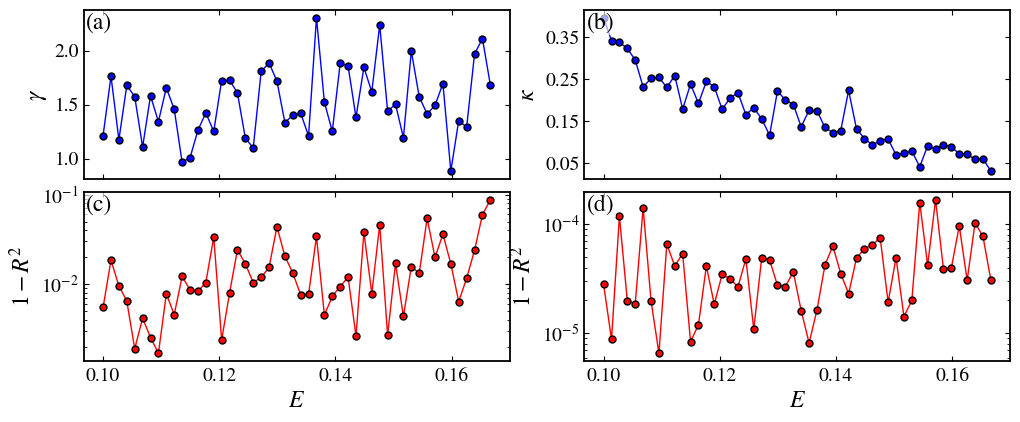

In [8]:
ps = PlotStyler(fontsize=17)
ps.apply_style()

fig, ax = plt.subplots(
    2,
    2,
    figsize=(10, 4),
    sharex="col",
)

# ==================================================
# sticky exponent
# ==================================================

ax[0, 0].plot(
    energies,
    gamma_values,
    "bo-",
)

ax[0, 0].set_ylabel(r"$\gamma$")

# ==================================================
# sticky R²
# ==================================================

ax[1, 0].plot(
    energies,
    1 - gamma_r2,
    "ro-",
)

ax[1, 0].set_yscale("log")
ax[1, 0].set_xlabel(r"$E$")
ax[1, 0].set_ylabel(r"$1 - R^2$")
# ax[1, 0].set_ylim(0.9, 1.02)

# ==================================================
# chaotic exponent
# ==================================================

ax[0, 1].plot(
    energies,
    kappa_values,
    "bo-",
)

ax[0, 1].set_ylabel(r"$\kappa$")
ax[0, 1].set_yticks([0.05, 0.15, 0.25, 0.35])

# ==================================================
# chaotic R²
# ==================================================

ax[1, 1].plot(
    energies,
    1 - kappa_r2,
    "ro-",
)
ax[1, 1].set_yscale("log")
ax[1, 1].set_xlabel(r"$E$")
ax[1, 1].set_ylabel(r"$1 - R^2$")
# ax[1, 1].set_ylim(0.9, 1.02)

# ==================================================
# cosmetics
# ==================================================

for i in range(2):
    for j in range(2):
        ps.set_tick_padding(ax[i, j], pad_x=5)

xbox = 0.006
ybox = 0.889
bbox = {
    "facecolor": "w",
    "linewidth": 0.0,
    "alpha": 0.65,
    "pad": 1,
}

for i in range(4):

    ax.flat[i].text(
        xbox,
        ybox,
        f"({abc[i]})",
        transform=ax.flat[i].transAxes,
        bbox=bbox,
    )

plt.subplots_adjust(
    left=0.072,
    bottom=0.1175,
    right=0.9985,
    top=0.995,
    wspace=0.175,
    hspace=0.08,
)

plt.savefig(
    "figures/fig8.png",
    dpi=600,
)

## Fig. 9

In [9]:
datafile = f"{path_to_data}/henon_heiles/data/prop_chaos_vs_E_N=10000_T=10000.0_num_ic=10000_rte_thr=2.50_sali_thr=1.0e-10.dat"
df = pd.read_csv(datafile, header=None, sep=r"\s+")

<Figure size 640x480 with 0 Axes>

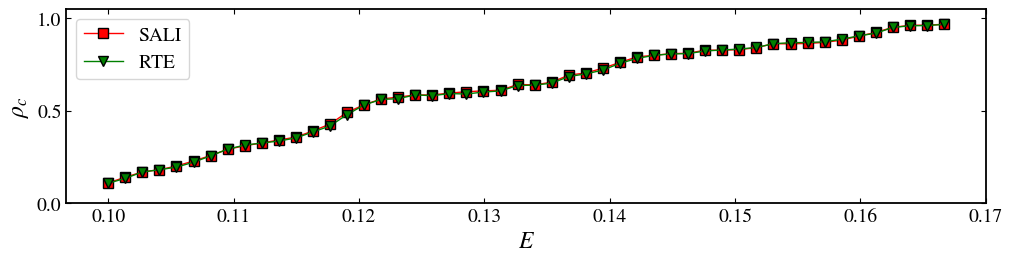

In [10]:
ps = PlotStyler(fontsize=17)
ps.apply_style()

fig, ax = plt.subplots(figsize=(10, 2.5))

plt.plot(df[0], df[3], "rs-", label="SALI", ms=7)
plt.plot(df[0], df[1], "gv-", label="RTE", ms=7)
plt.legend()
plt.xlabel("$E$")
plt.ylabel(r"$\rho_c$")
plt.ylim(-0.0, 1.05)
plt.tight_layout(pad=0.15)
plt.savefig("figures/fig9.png", dpi=400)

# Paradigm Hamiltonian

## Fig. 10

<Figure size 640x480 with 0 Axes>

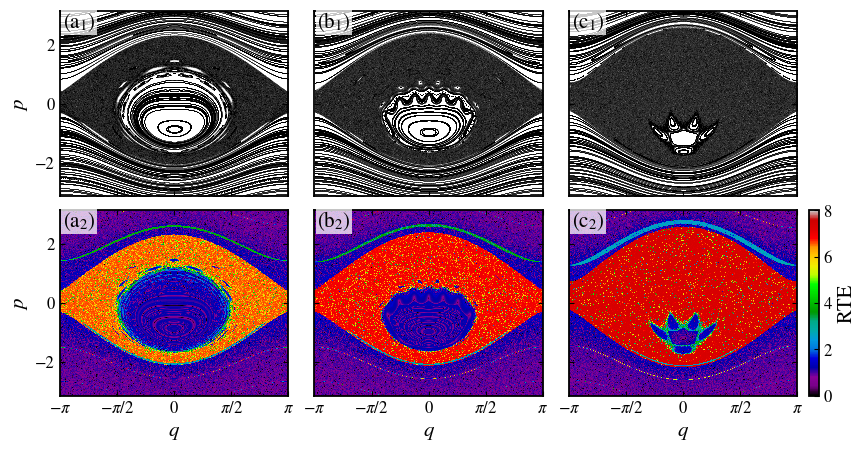

In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from pandas.errors import EmptyDataError

dt = 0.01
A_vals = [0.092, 0.132, 0.248]
n_cross = 10000
grid_size = 1000
fontsize = 15

ps = PlotStyler(fontsize=fontsize)
ps.apply_style()

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.15, hspace=0.075)

ax = np.empty((2, 3), dtype=object)
for j in range(3):
    ax[0, j] = fig.add_subplot(gs[0, j])
    ax[1, j] = fig.add_subplot(gs[1, j], sharex=ax[0, j], sharey=ax[0, j])

cax = fig.add_subplot(gs[1, 3])  # colorbar only for bottom row

for i, A in enumerate(A_vals):
    datafile = f"{path_to_data}/paradigm_hamiltonian/data/pss_A={A:.5f}_n={n_cross}.dat"
    df = pd.read_csv(datafile, header=None, sep=r"\s+")
    ax[0, i].plot(df[0], df[1], "ko", ms=0.1, markeredgewidth=0)

    datafile = f"{path_to_data}/paradigm_hamiltonian/data/grid_rte_A={A:.5f}_N={n_cross}_grid_size={grid_size}_scale=0.050.dat"
    df = pd.read_csv(datafile, header=None, sep=r"\s+")

    q = df[0].to_numpy().reshape(grid_size, grid_size)
    p = df[1].to_numpy().reshape(grid_size, grid_size)
    rte = df[2].to_numpy().reshape(grid_size, grid_size)

    hm = ax[1, i].pcolormesh(q, p, rte, cmap="nipy_spectral", vmin=0, vmax=8)
    if i > 0:
        ax[0, i].set_yticklabels([])
        ax[1, i].set_yticklabels([])

for a in ax.flat:
    a.set_xlim(-np.pi, np.pi)
    a.set_ylim(-np.pi, np.pi)

for i in range(3):
    ax[1, i].set_xlabel(r"$q$")
for i in range(2):
    ax[i, 0].set_ylabel(r"$p$")

for a in ax[0]:
    a.tick_params(labelbottom=False)

for a in ax[1]:
    a.set_xticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
        [r"$-\pi$", r"$-\pi/2$", "$0$", r"$\pi/2$", r"$\pi$"],
    )
xbox = 0.012
ybox = 0.91
bbox = {"facecolor": "w", "linewidth": 0.0, "alpha": 0.75, "pad": 1}
for i in range(ax.shape[1]):
    ax[0, i].text(
        xbox, ybox, f"({abc[i]}$_1$)", transform=ax[0, i].transAxes, bbox=bbox
    )
    ax[1, i].text(
        xbox, ybox, f"({abc[i]}$_2$)", transform=ax[1, i].transAxes, bbox=bbox
    )
pos = cax.get_position()
cax.set_position([pos.x0 - 0.015, pos.y0, 0.01, pos.height])
fig.colorbar(hm, cax=cax, label="RTE", aspect=30)
plt.savefig("figures/fig10.png", dpi=400, bbox_inches="tight")